# 4. Testing and Interpreting Model Results

1. Now that our variables have been selected

Features for OLS: ['interest_rate', 'Close_DX_Y_NYB']

--- 'Old World' OLS Model (Training Period) ---
                            OLS Regression Results                            
Dep. Variable:               gold_ret   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.6007
Date:                Wed, 08 Apr 2026   Prob (F-statistic):              0.548
Time:                        23:42:38   Log-Likelihood:                 5112.6
No. Observations:                2983   AIC:                        -1.022e+04
Df Residuals:                    2980   BIC:                        -1.020e+04
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
------------------------

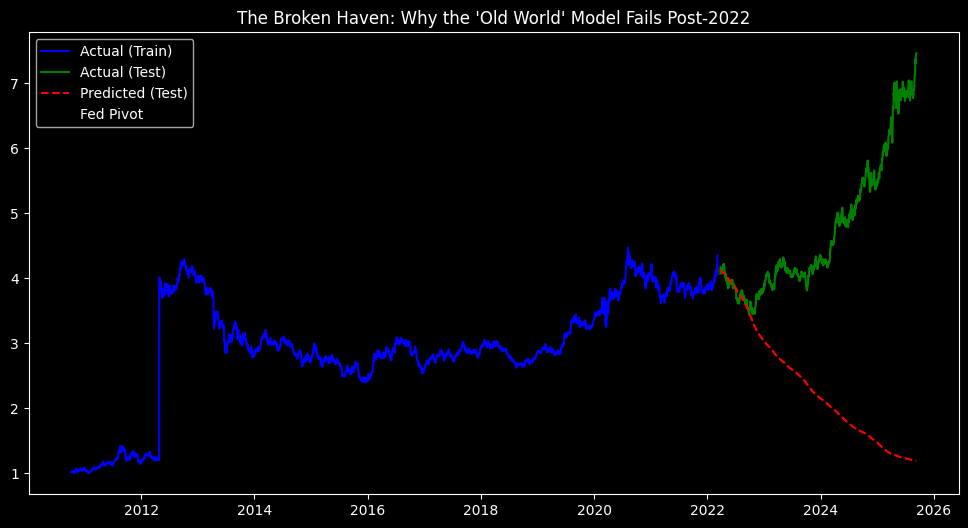

In [11]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# 1. Load the cleaned dataset
df = pd.read_csv('data/processed/final_model_data.csv', index_col='DATE', parse_dates=True)

# 2. Define the Split Date (The Fed Pivot)
# We use March 16, 2022: The day the "Safe Haven" rules began to shift
split_date = '2022-03-16'
train = df[df.index < split_date].copy()
test = df[df.index >= split_date].copy()

# 3. Features for LASSO Selection
# We exclude dummies/interactions here to find the "True" pre-2022 drivers
features = ['interest_rate', 'expected_inflation', 'wti_crude_oil_price',
            'sp500_ret', 'sp500_ret_lag', 'Close_VIX', 'Close_DX_Y_NYB']

# 4. LASSO Feature Selection (Training Set Only)
X_train_lasso = train[features]
y_train_lasso = train['gold_ret'] * 100  # Scaling up to improve sensitivity

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_lasso)

lasso = LassoCV(cv=5, random_state=42, max_iter=10000).fit(X_train_scaled, y_train_lasso)
selected_features = [f for f, s in zip(features, lasso.coef_ != 0) if s]

# Note: If LASSO is too aggressive, we manually ensure our hypothesis variables are included
required_vars = ['interest_rate', 'Close_DX_Y_NYB']
for var in required_vars:
    if var not in selected_features:
        selected_features.append(var)

print(f"Features for OLS: {selected_features}")

# 5. OLS Inference (The 'Old World' Baseline)
X_train_ols = sm.add_constant(train[selected_features])
y_train_ols = train['gold_ret']

# Using HC3 Robust Standard Errors to fix heteroskedasticity
ols_model = sm.OLS(y_train_ols, X_train_ols).fit(cov_type='HC3')
print("\n--- 'Old World' OLS Model (Training Period) ---")
print(ols_model.summary())

# 6. Testing the Model Failure (The "Broken Haven" Proof)
X_test_ols = sm.add_constant(test[selected_features])
test['pred_gold_ret'] = ols_model.predict(X_test_ols)

# Comparing RMSE
train_rmse = np.sqrt(mean_squared_error(train['gold_ret'], ols_model.predict(X_train_ols)))
test_rmse = np.sqrt(mean_squared_error(test['gold_ret'], test['pred_gold_ret']))

print("\n--- Prediction Accuracy Comparison ---")
print(f"Training RMSE: {train_rmse*100:.6f}") #multiply by 100 to get percentages
print(f"Testing RMSE: {test_rmse*100:.6f}")

# 7. Final Visual: Actual vs. Predicted Cumulative Returns
plt.figure(figsize=(12, 6))
train_cum = (1 + train['gold_ret']).cumprod()
test_actual_cum = train_cum.iloc[-1] * (1 + test['gold_ret']).cumprod()
test_pred_cum = train_cum.iloc[-1] * (1 + test['pred_gold_ret']).cumprod()

plt.plot(train_cum, label='Actual (Train)', color='blue')
plt.plot(test_actual_cum, label='Actual (Test)', color='green')
plt.plot(test_pred_cum, label='Predicted (Test)', color='red', linestyle='--')
plt.axvline(pd.to_datetime(split_date), color='black', alpha=0.5, label='Fed Pivot')
plt.title("The Broken Haven: Why the 'Old World' Model Fails Post-2022")
plt.legend()
plt.show()

In [10]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

# 1. Training: Using the objects already created in Part 1
# We use max_depth=3 to keep it simple and prevent overfitting on daily noise
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42)
xgb_model.fit(X_train_scaled, y_train_lasso)

# 2. Predict the 'New World' (Post-March 2022)
# Re-using the 'features' list and 'scaler' from Part 1
X_test = test[features]
X_test_scaled = scaler.transform(X_test)
test['pred_gold_ret_xgb'] = xgb_model.predict(X_test_scaled)

# 3. Calculate Errors
# CRITICAL: We must scale y_test by 100 to match y_train_lasso scaling
y_test_scaled = test['gold_ret'] * 100
train_preds_xgb = xgb_model.predict(X_train_scaled)

train_xgrmse = np.sqrt(mean_squared_error(y_train_lasso, train_preds_xgb))
test_xgrmse = np.sqrt(mean_squared_error(y_test_scaled, test['pred_gold_ret_xgb']))

print(f"XGBoost Training RMSE: {train_xgrmse:.6f}")
print(f"XGBoost Testing RMSE: {test_xgrmse:.6f}")
print(f"Error Increase: {((test_xgrmse/train_xgrmse)-1)*100:.2f}%")

# 4. Feature Importance (The "Econometrician" Insight)
# This shows what the AI thought was important BEFORE the haven broke
importance = pd.Series(xgb_model.feature_importances_, index=features).sort_values(ascending=False)
print("\nXGBoost Feature Importance (based on pre-covid training data):")
print(importance)

XGBoost Training RMSE: 1.042795
XGBoost Testing RMSE: 0.980703
Error Increase: -5.95%

XGBoost Feature Importance (based on pre-covid training data):
sp500_ret_lag          0.762049
Close_DX_Y_NYB         0.197411
wti_crude_oil_price    0.027974
interest_rate          0.006104
sp500_ret              0.002774
Close_VIX              0.002499
expected_inflation     0.001189
dtype: float32
